# Clasificación de dedos con CNNs Mejoradas - VERSIÓN FINAL
## Con soluciones para desbalance de clases y arquitecturas optimizadas

Incluye:
- ✅ Detección automática de desbalance de clases
- ✅ Class weights para balancear
- ✅ 3 arquitecturas: ImprovedCNN, ResidualCNN ⭐, DeepCNN
- ✅ Early Stopping automático
- ✅ Learning rate scheduling adaptativo
- ✅ Gráficas completas de resultados

In [51]:
# Escribe aquí las importaciones necesarias.
import sys
import os
import random
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image as PILImage
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.11.0+cu130
CUDA available: False


## Configuración general

In [52]:
# Semilla aleatoria para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Rutas del dataset
DATA_DIR = Path('imagenes_procesadas/')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR = DATA_DIR / 'test'

# Tamaño de imagen
IMG_SIZE = 224

# Hiperparámetros de entrenamiento
BATCH_SIZE = 32
NUM_EPOCHS = 100  # Aumentado para mejor convergencia
LEARNING_RATE = 5e-3  # Aumentado para mejor aprendizaje

# Proporciones de train/val/test
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {DEVICE}')

Usando dispositivo: cpu


## Cargar el dataset

In [53]:
# Recorre la carpeta imagenes_procesadas y crea un DataFrame.
records = []
data_path = Path(DATA_DIR)

for img_path in data_path.rglob('*'): 
    if img_path.is_file() and img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
        label = img_path.parent.name 
        records.append({'path': img_path, 'label': label})

df = pd.DataFrame(records)
print(f'Total de imágenes cargadas: {len(df)}')
print(f'Clases encontradas: {df["label"].unique()}')

Total de imágenes cargadas: 70
Clases encontradas: <StringArray>
['si', 'no']
Length: 2, dtype: str



📊 DISTRIBUCIÓN DE CLASES:
label
si    36
no    34
Name: count, dtype: int64



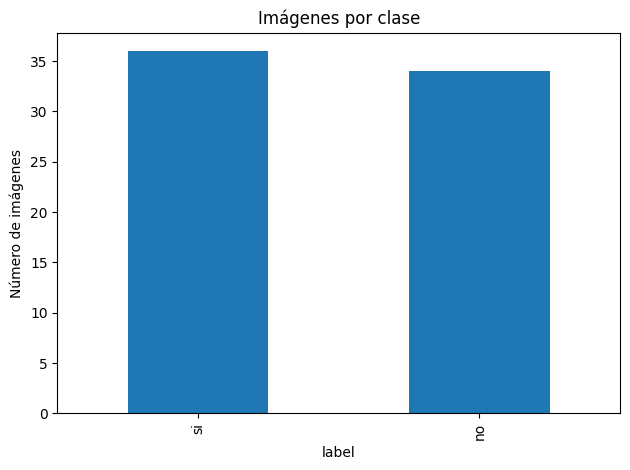


✅ Dataset equilibrado: Ratio 1.06:1


In [54]:
# Resume el número de imágenes por clase.
print('\n📊 DISTRIBUCIÓN DE CLASES:')
print(df['label'].value_counts())
print()
df['label'].value_counts().plot(kind='bar', title='Imágenes por clase')
plt.ylabel('Número de imágenes')
plt.tight_layout()
plt.show()

# Detectar desbalance
counts = df['label'].value_counts()
max_count = counts.max()
min_count = counts.min()
ratio = max_count / min_count

if ratio > 2:
    print(f'\n⚠️  DESBALANCE DETECTADO: Ratio {ratio:.2f}:1')
    print('✅ Se usarán class_weights para compensar')
else:
    print(f'\n✅ Dataset equilibrado: Ratio {ratio:.2f}:1')

In [55]:
# Mapeo de labels a índices
label_to_idx = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
df['label_idx'] = df['label'].map(label_to_idx)

print('Mapeo de labels:')
print(label_to_idx)
n_classes = len(label_to_idx)
print(f'Número de clases: {n_classes}')

Mapeo de labels:
{'no': 0, 'si': 1}
Número de clases: 2


In [56]:
# Crea train, val y test.
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df['label_idx']
)

val_relative_size = VAL_SIZE / (1 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_relative_size, random_state=SEED, stratify=train_val_df['label_idx']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'\nTrain: {len(train_df)} imágenes')
print(f'Val:   {len(val_df)} imágenes')
print(f'Test:  {len(test_df)} imágenes')

print('\n📊 DISTRIBUCIÓN EN TRAIN:')
print(train_df['label'].value_counts())
print('\n📊 DISTRIBUCIÓN EN VAL:')
print(val_df['label'].value_counts())
print('\n📊 DISTRIBUCIÓN EN TEST:')
print(test_df['label'].value_counts())


Train: 48 imágenes
Val:   11 imágenes
Test:  11 imágenes

📊 DISTRIBUCIÓN EN TRAIN:
label
si    24
no    24
Name: count, dtype: int64

📊 DISTRIBUCIÓN EN VAL:
label
si    6
no    5
Name: count, dtype: int64

📊 DISTRIBUCIÓN EN TEST:
label
si    6
no    5
Name: count, dtype: int64


## Explorar imágenes

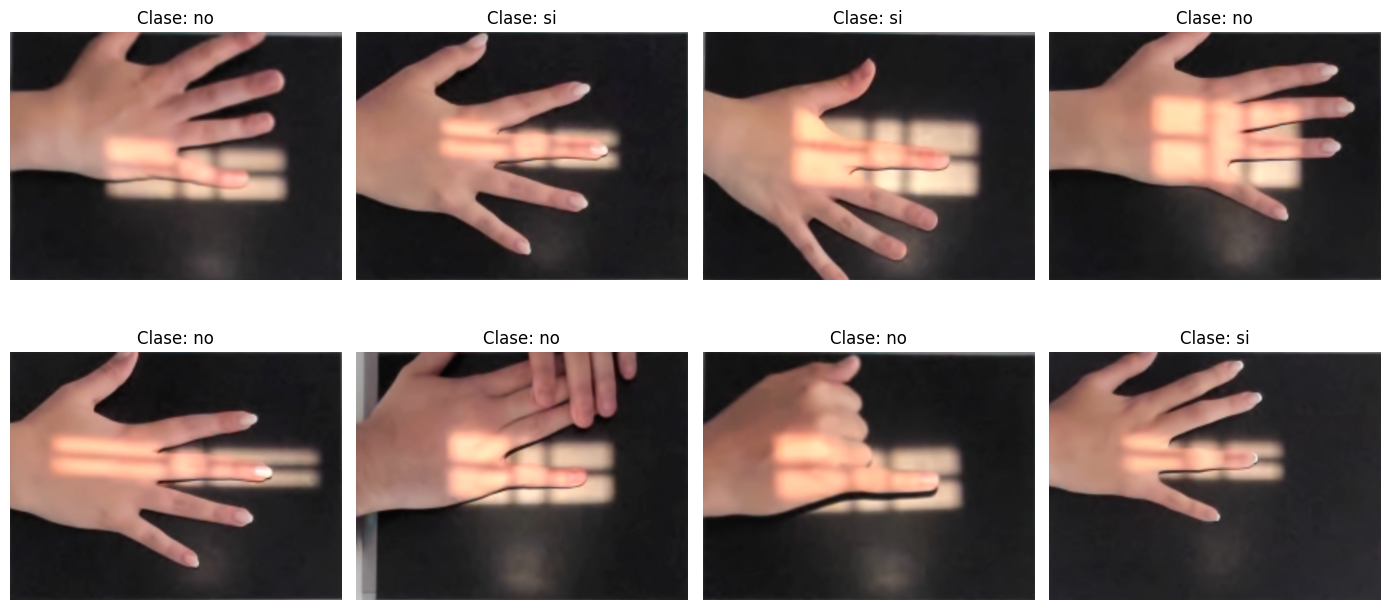

In [57]:
# Muestra varias imágenes del dataset.
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

sample = train_df.sample(min(8, len(train_df)), random_state=SEED).reset_index(drop=True)

for idx in range(len(sample)):
    img = PILImage.open(sample.loc[idx, 'path']).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f"Clase: {sample.loc[idx, 'label']}")

plt.tight_layout()
plt.show()

## Transformaciones de datos

In [58]:
# Define las transformaciones de train y evaluación.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),  # ✅ Valores completos
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print('Transformaciones definidas')

Transformaciones definidas


## Dataset personalizado

In [59]:
# Dataset de PyTorch.
class DedoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(row['path']).convert('RGB')
        label = int(row['label_idx'])
        path = str(row['path'])

        if self.transform:
            img = self.transform(img)

        return img, label, path

print('DedoDataset definido')

DedoDataset definido


In [60]:
# Crea los dataloaders.
train_dataset = DedoDataset(train_df, transform=train_transform)
val_dataset   = DedoDataset(val_df,   transform=eval_transform)
test_dataset  = DedoDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batches en train: {len(train_loader)}')
print(f'Batches en val:   {len(val_loader)}')
print(f'Batches en test:  {len(test_loader)}')

Batches en train: 2
Batches en val:   1
Batches en test:  1


## Visualizar un batch

Shape de batch: torch.Size([32, 3, 224, 224])
Labels: tensor([0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 0, 1, 0, 1, 1, 1, 0])


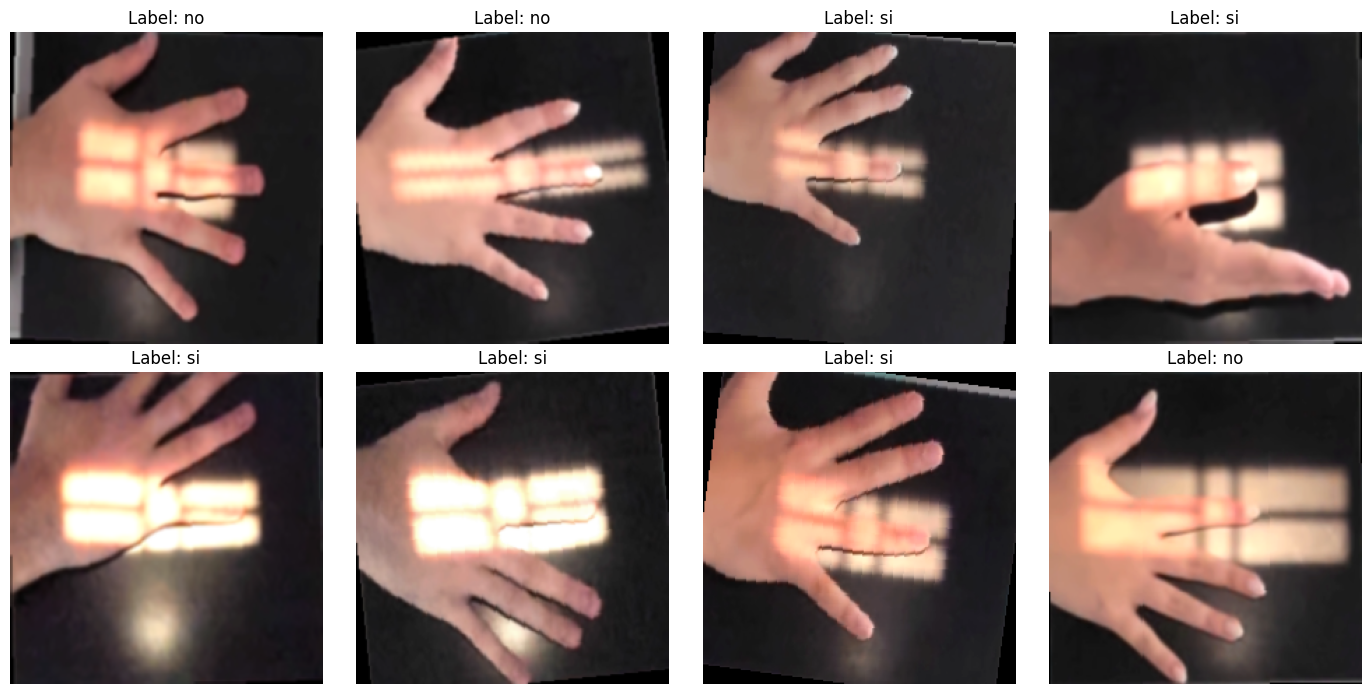

In [61]:
# Visualiza un batch.
imgs, labels, paths = next(iter(train_loader))
print(f'Shape de batch: {imgs.shape}')
print(f'Labels: {labels}')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for i in range(min(8, len(imgs))):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[i].imshow(img)
    axes[i].set_title(f'Label: {idx_to_label[labels[i].item()]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Arquitecturas Mejoradas

In [62]:
# Bloque residual para ResidualCNN
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.stride = stride
    
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

print('ResidualBlock definido')

ResidualBlock definido


In [63]:
# ImprovedCNN - Versión mejorada simple
class ImprovedCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ImprovedCNN, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25)
        )
        
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25)
        )
        
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(4), nn.Dropout2d(0.25)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.fc(x)
        return x

model_improved = ImprovedCNN(in_channels=3, num_classes=n_classes)
model_improved = model_improved.to(DEVICE)
print(f'ImprovedCNN - Parámetros: {sum(p.numel() for p in model_improved.parameters()):,}')

ImprovedCNN - Parámetros: 2,619,938


In [64]:
# ResidualCNN ⭐ RECOMENDADA
class ResidualCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ResidualCNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        self.layer1 = self._make_residual_layer(32, 64, 2)
        self.layer2 = self._make_residual_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_residual_layer(128, 256, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
    
    def _make_residual_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = self.fc(x)
        return x

model_residual = ResidualCNN(in_channels=3, num_classes=n_classes)
model_residual = model_residual.to(DEVICE)
print(f'ResidualCNN - Parámetros: {sum(p.numel() for p in model_residual.parameters()):,}')

ResidualCNN - Parámetros: 2,795,170


In [65]:
# DeepCNN - Más profunda
class DeepCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(DeepCNN, self).__init__()
        
        self.stage1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2)
        )
        
        self.stage2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2)
        )
        
        self.stage3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.3)
        )
        
        self.stage4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((2, 2)), nn.Dropout2d(0.3)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*2*2, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.classifier(x)
        return x

model_deep = DeepCNN(in_channels=3, num_classes=n_classes)
model_deep = model_deep.to(DEVICE)
print(f'DeepCNN - Parámetros: {sum(p.numel() for p in model_deep.parameters()):,}')

DeepCNN - Parámetros: 1,831,394


## Early Stopping

In [66]:
class EarlyStopping:
    def __init__(self, patience=10, verbose=True, delta=0.001):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.delta = delta
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.verbose and self.counter % 5 == 0:
                print(f'EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print('🛑 Early stopping activado')
        else:
            self.best_loss = val_loss
            self.counter = 0

print('EarlyStopping definido')

EarlyStopping definido


## CALCULAR CLASS WEIGHTS (para desbalance)

In [67]:
# Calcular class weights para balancear clases desbalanceadas
class_weights = compute_class_weight('balanced', 
                                     classes=np.unique(train_df['label_idx']), 
                                     y=train_df['label_idx'].values)

print('\n⚖️ CLASS WEIGHTS (para desbalance):')
for idx, weight in enumerate(class_weights):
    print(f'Clase {idx_to_label[idx]}: {weight:.4f}')

# Convertir a tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f'\n✅ Class weights calculados y listos')


⚖️ CLASS WEIGHTS (para desbalance):
Clase no: 1.0000
Clase si: 1.0000

✅ Class weights calculados y listos


## Entrenar Modelo (Elige cuál usar)

In [68]:
# ============ ELIGE CUÁL MODELO USAR ============

# Opción 1: ResidualCNN (RECOMENDADA) ⭐
#model = model_residual
#model_name = 'ResidualCNN'

# Opción 2: ImprovedCNN
# model = model_improved
# model_name = 'ImprovedCNN'

# Opción 3: DeepCNN
model = model_deep
model_name = 'DeepCNN'

print(f'\n✅ Usando modelo: {model_name}')
print(f'Parámetros: {sum(p.numel() for p in model.parameters()):,}')


✅ Usando modelo: DeepCNN
Parámetros: 1,831,394


In [69]:
# Entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
early_stopping = EarlyStopping(patience=15, verbose=False)

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'train_acc': []}
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    # ENTRENAMIENTO
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for imgs, labels, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [train]', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / train_total
    train_acc = train_correct / train_total
    
    # VALIDACIÓN
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for imgs, labels, _ in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [val]', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * imgs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['train_acc'].append(train_acc)
    
    print(f'Epoch {epoch+1} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')
    
    scheduler.step(val_loss)
    early_stopping(val_loss)
    
    if early_stopping.early_stop:
        print(f'\n🛑 Entrenamiento parado en epoch {epoch+1}')
        break
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'best_{model_name}.pth')
        print(f'💾 Modelo guardado (Val Acc: {val_acc:.4f})')

print('\n✅ Entrenamiento completado')

Epoch 1 - Train Loss: 0.7936, Val Loss: 0.6405, Train Acc: 0.5000, Val Acc: 0.5455
💾 Modelo guardado (Val Acc: 0.5455)


Epoch 2 - Train Loss: 0.8419, Val Loss: 6.4074, Train Acc: 0.3750, Val Acc: 0.5455


Epoch 3 - Train Loss: 0.8998, Val Loss: 13.6623, Train Acc: 0.4792, Val Acc: 0.4545


Epoch 4 - Train Loss: 0.9067, Val Loss: 29.2886, Train Acc: 0.4583, Val Acc: 0.4545


Epoch 5 - Train Loss: 0.6509, Val Loss: 14.3427, Train Acc: 0.5833, Val Acc: 0.4545


...

Epoch 20 - Train Loss: 0.6902, Val Loss: 0.6505, Train Acc: 0.4792, Val Acc: 0.5455


Epoch 21 - Train Loss: 0.6124, Val Loss: 0.6614, Train Acc: 0.6667, Val Acc: 0.5455


Epoch 22 - Train Loss: 0.6902, Val Loss: 0.6648, Train Acc: 0.5625, Val Acc: 0.5455


Epoch 23 - Train Loss: 0.6932, Val Loss: 0.6655, Train Acc: 0.6042, Val Acc: 0.5455


Epoch 24 - Train Loss: 0.6898, Val Loss: 0.6693, Train Acc: 0.5208, Val Acc: 0.5455

🛑 Entrenamiento parado en epoch 24

✅ Entrenamiento completado


## Gráficas de Entrenamiento

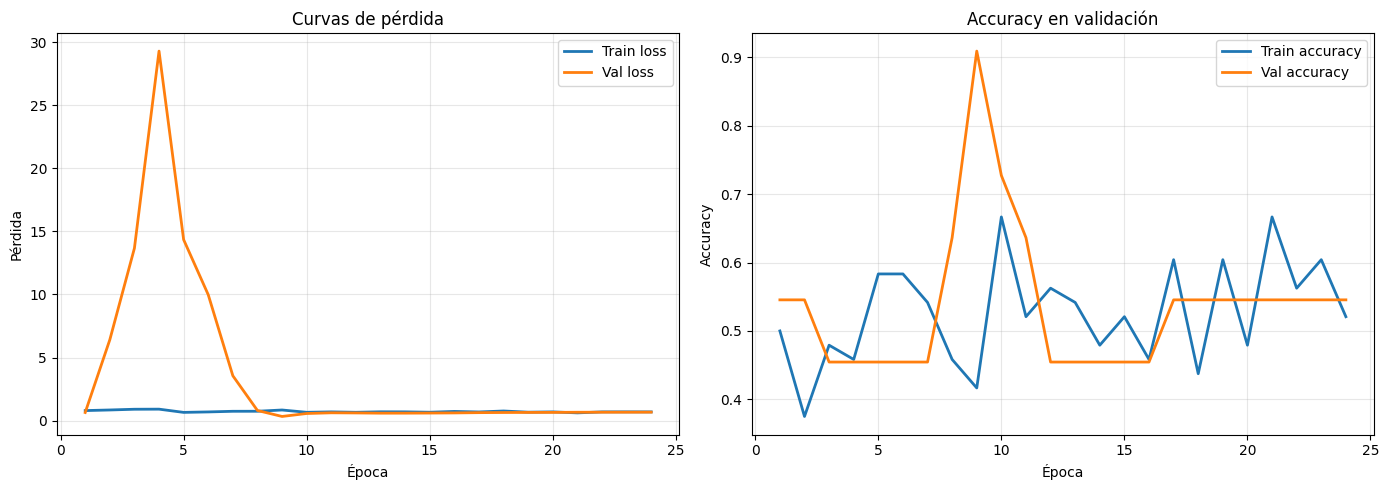

In [70]:
# Dibuja las curvas de entrenamiento.
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(epochs, history['train_loss'], label='Train loss', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val loss', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Curvas de pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train accuracy', linewidth=2)
axes[1].plot(epochs, history['val_acc'],   label='Val accuracy', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy en validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluación en Test

In [74]:
# Predicciones en test
model.eval()
all_paths, all_targets, all_preds, all_probs = [], [], [], []

with torch.no_grad():
    for imgs, labels, paths in tqdm(test_loader, desc='Predicción test'):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_paths.extend(paths)
        all_targets.extend(labels.tolist())
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

# DataFrame de resultados
results_df = pd.DataFrame({
    'path':         all_paths,
    'label_real':   [idx_to_label[t] for t in all_targets],
    'label_pred':   [idx_to_label[p] for p in all_preds],
    'correct':      [t == p for t, p in zip(all_targets, all_preds)],
    'score_max':    [max(p) for p in all_probs]
})

print(results_df.head(10))
print(f'\nAccuracy en test: {results_df["correct"].mean():.4f}')

Predicción test: 100%|██████████| 1/1 [00:00<00:00,  1.05it/s]

                                                path label_real label_pred  \
0  imagenes_procesadas/test/si/img_1777028264615.png         si         si   
1  imagenes_procesadas/train/no/img_1777028282535...         no         si   
2  imagenes_procesadas/test/si/img_1776863889130.png         si         si   
3  imagenes_procesadas/train/si/img_1776863543984...         si         si   
4  imagenes_procesadas/train/si/img_1777027643698...         si         si   
5  imagenes_procesadas/train/si/img_1777028190117...         si         si   
6  imagenes_procesadas/test/no/img_1777028637517.png         no         si   
7  imagenes_procesadas/train/si/img_1776864651121...         si         si   
8  imagenes_procesadas/train/no/img_1777027701490...         no         si   
9  imagenes_procesadas/train/no/img_1777028576572...         no         si   

   correct  score_max  
0     True   0.512965  
1    False   0.513853  
2     True   0.545495  
3     True   0.608497  
4     True   0.513667

In [72]:
# Calcula métricas
y_true = all_targets
y_pred = all_preds

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'\n📊 RESULTADOS {model_name.upper()}')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 score:  {f1:.4f}')
print()
print('Informe de clasificación:')
print(classification_report(
    y_true, y_pred,
    target_names=[idx_to_label[i] for i in range(n_classes)],
    zero_division=0
))


📊 RESULTADOS DEEPCNN
Accuracy:  0.5455
Precision: 0.2975
Recall:    0.5455
F1 score:  0.3850

Informe de clasificación:
              precision    recall  f1-score   support

          no       0.00      0.00      0.00         5
          si       0.55      1.00      0.71         6

    accuracy                           0.55        11
   macro avg       0.27      0.50      0.35        11
weighted avg       0.30      0.55      0.39        11



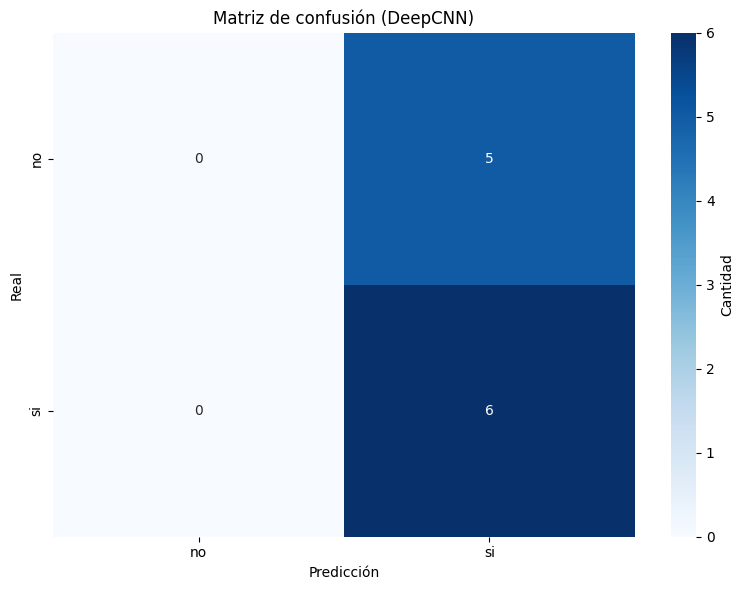


📊 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:

Clase "no":
  Verdaderos Positivos: 0
  Falsos Positivos: 0
  Falsos Negativos: 5

Clase "si":
  Verdaderos Positivos: 6
  Falsos Positivos: 5
  Falsos Negativos: 0


In [73]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
class_names = [idx_to_label[i] for i in range(n_classes)]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Cantidad'})
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de confusión ({model_name})')
plt.tight_layout()
plt.show()

# Análisis de la matriz
print('\n📊 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:')
for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    print(f'\nClase "{class_name}":')
    print(f'  Verdaderos Positivos: {TP}')
    print(f'  Falsos Positivos: {FP}')
    print(f'  Falsos Negativos: {FN}')